In [ ]:
# Mount Drive and basic imports
from google.colab import drive
drive.mount("/content/drive")

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_curve, auc
from tqdm.auto import tqdm


Mounted at /content/drive


In [ ]:
# Reproducibility and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [ ]:
# Unzip PA dataset
ZIP_PATH = "/content/drive/MyDrive/PA.zip"
EXTRACT_PATH = "/content"

assert os.path.exists(ZIP_PATH), f"Zip not found: {ZIP_PATH}"
!unzip -qo "/content/drive/MyDrive/PA.zip" -d "/content/"

print(os.listdir(EXTRACT_PATH))


['.config', 'PA', 'drive', 'sample_data']


In [ ]:
# Auto-detect dataset root
candidates = [
    Path("/content/PA"),
    Path("/content/ASVspoof2019_PA"),
    Path("/content")
]

DATASET_PATH = None
for cand in candidates:
    if (cand / "ASVspoof2019_PA_cm_protocols").exists():
        DATASET_PATH = str(cand)
        break

if DATASET_PATH is None:
    raise FileNotFoundError("Could not find ASVspoof2019_PA_cm_protocols after unzip.")

PROTOCOL_DIR = os.path.join(DATASET_PATH, "ASVspoof2019_PA_cm_protocols")
TRAIN_AUDIO_DIR = os.path.join(DATASET_PATH, "ASVspoof2019_PA_train", "flac")
DEV_AUDIO_DIR = os.path.join(DATASET_PATH, "ASVspoof2019_PA_dev", "flac")

print("DATASET_PATH:", DATASET_PATH)
print("PROTOCOL_DIR exists:", os.path.exists(PROTOCOL_DIR))
print("TRAIN_AUDIO_DIR exists:", os.path.exists(TRAIN_AUDIO_DIR))
print("DEV_AUDIO_DIR exists:", os.path.exists(DEV_AUDIO_DIR))


DATASET_PATH: /content/PA
PROTOCOL_DIR exists: True
TRAIN_AUDIO_DIR exists: True
DEV_AUDIO_DIR exists: True


In [ ]:
# Protocol parsing
def parse_protocol(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            file_id = parts[1]
            label = 1 if parts[-1] == "bonafide" else 0
            records.append({"file": file_id, "label": label})
    return pd.DataFrame(records)

TRAIN_PROTOCOL = os.path.join(PROTOCOL_DIR, "ASVspoof2019.PA.cm.train.trn.txt")
DEV_PROTOCOL = os.path.join(PROTOCOL_DIR, "ASVspoof2019.PA.cm.dev.trl.txt")

train_df = parse_protocol(TRAIN_PROTOCOL)
dev_df = parse_protocol(DEV_PROTOCOL)

print("Train size:", len(train_df))
print("Dev size:", len(dev_df))
print(train_df["label"].value_counts())
print(dev_df["label"].value_counts())


Train size: 54000
Dev size: 29700
label
0    48600
1     5400
Name: count, dtype: int64
label
0    24300
1     5400
Name: count, dtype: int64


In [ ]:
# Feature extraction
SR = 16000
N_MELS = 80
TARGET_FRAMES = 288

def extract_logmel(y, sr=SR, n_mels=N_MELS):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=512,
        hop_length=160,
        win_length=400,
        n_mels=n_mels,
        power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    return logmel

def fix_length(spec, target_frames=TARGET_FRAMES):
    cur_frames = spec.shape[1]
    if cur_frames < target_frames:
        pad = target_frames - cur_frames
        spec = np.pad(spec, ((0, 0), (0, pad)), mode="constant")
    else:
        spec = spec[:, :target_frames]
    return spec.astype(np.float32)

def build_cache(dataframe, audio_dir, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f"Building cache: {os.path.basename(save_dir)}"):
        file_id = row["file"]
        save_path = os.path.join(save_dir, file_id + ".npy")

        if os.path.exists(save_path):
            continue

        audio_path = os.path.join(audio_dir, file_id + ".flac")
        y, sr = librosa.load(audio_path, sr=SR)

        logmel = extract_logmel(y, sr)
        logmel = fix_length(logmel)

        np.save(save_path, logmel)


In [ ]:
# Local cache in /content for speed
CACHE_ROOT = "/content/PA_cache"
TRAIN_CACHE = os.path.join(CACHE_ROOT, "train")
DEV_CACHE = os.path.join(CACHE_ROOT, "dev")

build_cache(train_df, TRAIN_AUDIO_DIR, TRAIN_CACHE)
build_cache(dev_df, DEV_AUDIO_DIR, DEV_CACHE)

print("Train cache files:", len(os.listdir(TRAIN_CACHE)))
print("Dev cache files:", len(os.listdir(DEV_CACHE)))


Building cache: train:   0%|          | 0/54000 [00:00<?, ?it/s]

Görüntülenen çıkış son 5000 satıra kısaltıldı.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3868/2861224712.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3868/2861224712.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3868/28612247

Building cache: dev:   0%|          | 0/29700 [00:00<?, ?it/s]

Görüntülenen çıkış son 5000 satıra kısaltıldı.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3868/2861224712.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3868/2861224712.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3868/28612247

Train cache files: 54000
Dev cache files: 29700


In [ ]:
CACHE_ROOT = "/content/PA_cache"
TRAIN_CACHE = os.path.join(CACHE_ROOT, "train")
DEV_CACHE = os.path.join(CACHE_ROOT, "dev")

os.makedirs(TRAIN_CACHE, exist_ok=True)
os.makedirs(DEV_CACHE, exist_ok=True)

if len(os.listdir(TRAIN_CACHE)) != len(train_df):
    build_cache(train_df, TRAIN_AUDIO_DIR, TRAIN_CACHE)
else:
    print("Train cache already ready")

if len(os.listdir(DEV_CACHE)) != len(dev_df):
    build_cache(dev_df, DEV_AUDIO_DIR, DEV_CACHE)
else:
    print("Dev cache already ready")


Train cache already ready
Dev cache already ready


In [ ]:
# Datasets and augmentation
def spec_augment(spec, freq_mask=4, time_mask=10):
    spec = spec.copy()

    f = random.randint(0, freq_mask)
    if f > 0 and spec.shape[0] - f > 0:
        f0 = random.randint(0, spec.shape[0] - f)
        spec[f0:f0+f, :] = 0

    t = random.randint(0, time_mask)
    if t > 0 and spec.shape[1] - t > 0:
        t0 = random.randint(0, spec.shape[1] - t)
        spec[:, t0:t0+t] = 0

    return spec

class CachedASVspoofDataset(Dataset):
    def __init__(self, dataframe, cache_dir, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.cache_dir = cache_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_id = row["file"]
        label = row["label"]

        feature_path = os.path.join(self.cache_dir, file_id + ".npy")
        logmel = np.load(feature_path)

        if self.augment:
            logmel = spec_augment(logmel)

        x = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(label, dtype=torch.long)
        return x, y

cached_train_dataset = CachedASVspoofDataset(train_df, TRAIN_CACHE, augment=False)
aug_train_dataset = CachedASVspoofDataset(train_df, TRAIN_CACHE, augment=True)
cached_dev_dataset = CachedASVspoofDataset(dev_df, DEV_CACHE, augment=False)

BATCH_SIZE = 64 if torch.cuda.is_available() else 16

cached_train_loader = DataLoader(
    cached_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False
)

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False
)

dev_loader = DataLoader(
    cached_dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False
)

print("Batch size:", BATCH_SIZE)


Batch size: 64


In [ ]:
# Model
class MFM(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels * 2,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )

    def forward(self, x):
        x = self.conv(x)
        x1, x2 = torch.chunk(x, 2, dim=1)
        return torch.max(x1, x2)

class LCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            MFM(1, 16),
            nn.MaxPool2d(2),
            MFM(16, 32),
            nn.MaxPool2d(2),
            MFM(32, 64),
            nn.MaxPool2d(2),
            MFM(64, 64),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 18, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

counts = train_df["label"].value_counts()
num_spoof = counts[0]
num_real = counts[1]

class_weights = torch.tensor(
    [1.0 / num_spoof, 1.0 / num_real],
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

def make_model_and_optimizer():
    model = LCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    return model, optimizer


In [ ]:
# Train and eval helpers
def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch_idx, total_epochs):
    model.train()
    total_loss = 0.0

    progress = tqdm(loader, desc=f"Epoch {epoch_idx}/{total_epochs}", leave=False)

    for batch_x, batch_y in progress:
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)

def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_scores(model, loader):
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=True)

            outputs = model(batch_x)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(batch_y.numpy())

    return np.array(all_scores), np.array(all_labels)

def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = fpr[idx]
    eer_threshold = thresholds[idx]
    return eer, eer_threshold

def train_model(model, train_loader, dev_loader, optimizer, criterion, epochs, save_path):
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_dev_loss = float("inf")
    train_history = []
    dev_history = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler,
            epoch_idx=epoch + 1, total_epochs=epochs
        )
        dev_loss = evaluate_loss(model, dev_loader, criterion)

        train_history.append(train_loss)
        dev_history.append(dev_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Dev Loss: {dev_loss:.4f}")

        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            torch.save(model.state_dict(), save_path)
            print("Best model saved")

    return train_history, dev_history


In [ ]:
# Fair experiment: same epochs, fresh model each time
EPOCHS = 15

BASE_MODEL_PATH = "/content/PA_baseline_best.pt"
AUG_MODEL_PATH = "/content/PA_aug_best.pt"

# Baseline
model_base, optimizer_base = make_model_and_optimizer()
base_train_history, base_dev_history = train_model(
    model_base,
    cached_train_loader,
    dev_loader,
    optimizer_base,
    criterion,
    epochs=EPOCHS,
    save_path=BASE_MODEL_PATH
)

model_base.load_state_dict(torch.load(BASE_MODEL_PATH, map_location=device))
scores_base, labels = evaluate_scores(model_base, dev_loader)
eer_base, thr_base = compute_eer(labels, scores_base)

# Augmented
model_aug, optimizer_aug = make_model_and_optimizer()
aug_train_history, aug_dev_history = train_model(
    model_aug,
    aug_train_loader,
    dev_loader,
    optimizer_aug,
    criterion,
    epochs=EPOCHS,
    save_path=AUG_MODEL_PATH
)

model_aug.load_state_dict(torch.load(AUG_MODEL_PATH, map_location=device))
scores_aug, _ = evaluate_scores(model_aug, dev_loader)
eer_aug, thr_aug = compute_eer(labels, scores_aug)

print(f"Baseline EER : {eer_base * 100:.2f}%")
print(f"Augmented EER: {eer_aug * 100:.2f}%")
print(f"Relative improvement: {(eer_base - eer_aug) / eer_base * 100:.2f}%")


/tmp/ipykernel_3868/3346676389.py:68: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Epoch 1/15:   0%|          | 0/844 [00:00<?, ?it/s]

/tmp/ipykernel_3868/3346676389.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 1/15 | Train Loss: 0.5555 | Dev Loss: 0.4222
Best model saved


Epoch 2/15:   0%|          | 0/844 [00:00<?, ?it/s]

...

Epoch 13/15 | Train Loss: 0.1849 | Dev Loss: 0.2489


Epoch 14/15:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.1735 | Dev Loss: 0.2402
Best model saved


Epoch 15/15:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.1664 | Dev Loss: 0.2606
Baseline EER : 12.77%
Augmented EER: 11.01%
Relative improvement: 13.79%


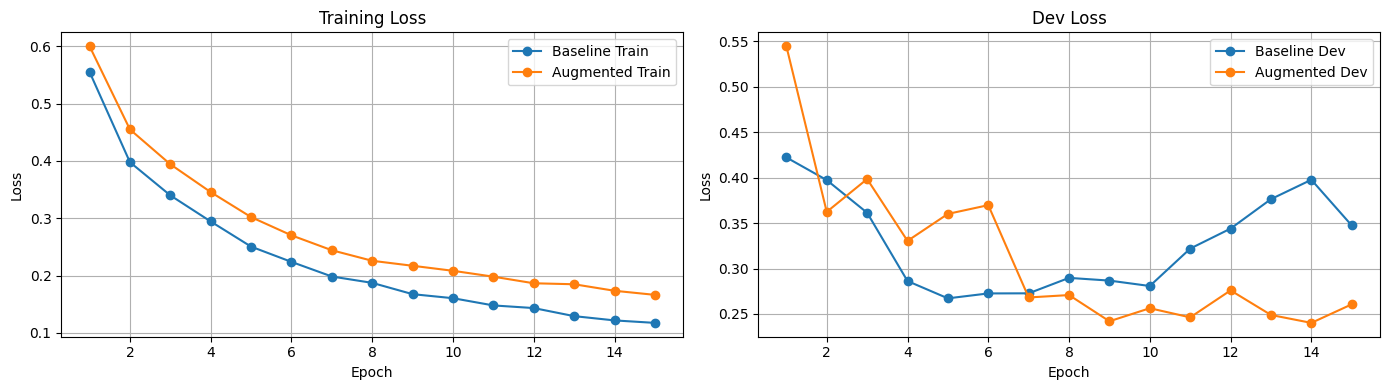

In [ ]:
# Plots
epochs_axis = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_axis, base_train_history, marker="o", label="Baseline Train")
axes[0].plot(epochs_axis, aug_train_history, marker="o", label="Augmented Train")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_axis, base_dev_history, marker="o", label="Baseline Dev")
axes[1].plot(epochs_axis, aug_dev_history, marker="o", label="Augmented Dev")
axes[1].set_title("Dev Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


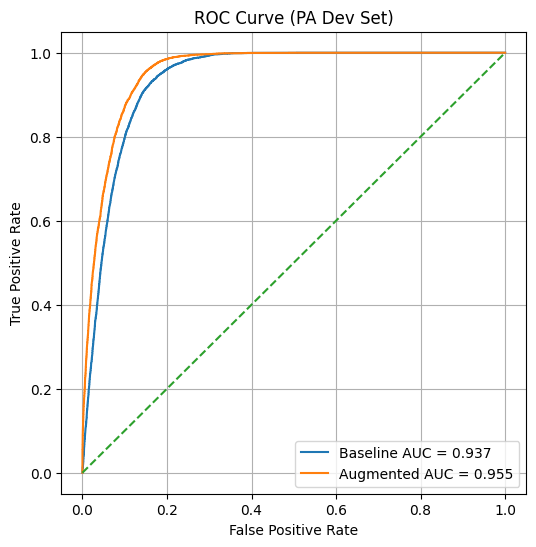

In [ ]:
# ROC comparison
fpr_base, tpr_base, _ = roc_curve(labels, scores_base)
fpr_aug, tpr_aug, _ = roc_curve(labels, scores_aug)

auc_base = auc(fpr_base, tpr_base)
auc_aug = auc(fpr_aug, tpr_aug)

plt.figure(figsize=(6, 6))
plt.plot(fpr_base, tpr_base, label=f"Baseline AUC = {auc_base:.3f}")
plt.plot(fpr_aug, tpr_aug, label=f"Augmented AUC = {auc_aug:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (PA Dev Set)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
torch.save(model.state_dict(), "pa_model.pth")

NameError: name 'model' is not defined